# 04 - Anomaly detection for risky-driving windows

Goal: flag the windows that look unusual relative to the rest of the
dataset, on the working assumption that aggressive / risky driving
manifests as statistical anomalies in the sensor stream.

Models compared:

- **Isolation Forest** - tree-based, fast, no distributional assumption.
- **One-Class SVM** (RBF) - boundary-based, complementary geometry.
- **Local Outlier Factor** - density-based, captures locally unusual points.

We also build a *heuristic* composite risk score directly from
interpretable indicators (e.g. lateral-acceleration variance, peak brake
pressure). This is **not ground truth** - we have no risk labels in this
dataset - it is just another lens on the same windows. We sanity-check
that the model-flagged anomalies and the heuristic risk score broadly
agree.


In [1]:
import sys, os
from pathlib import Path

# Make the project root importable so that `import src` works no matter where
# Jupyter was launched from.
HERE = Path(os.getcwd()).resolve()
ROOT = HERE if (HERE / "src").is_dir() else HERE.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("project root:", ROOT)


project root: C:\Users\moham\Desktop\Projects\Driver_assessment_classification_model


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import PCA

from src.io import load_cleaned
from src.features import build_window_feature_table, feature_columns, BEHAVIOR_SENSORS

sns.set_theme(style="whitegrid")
RNG = 42
CONTAMINATION = 0.15  # working hypothesis: ~15% of windows are unusual.


## 1. Build window features and inspect distributions

C:\Users\moham\Desktop\Projects\Driver_assessment_classification_model\src\features.py:57: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  vskew = float(skew(values, bias=False))


windows: (4997, 64)


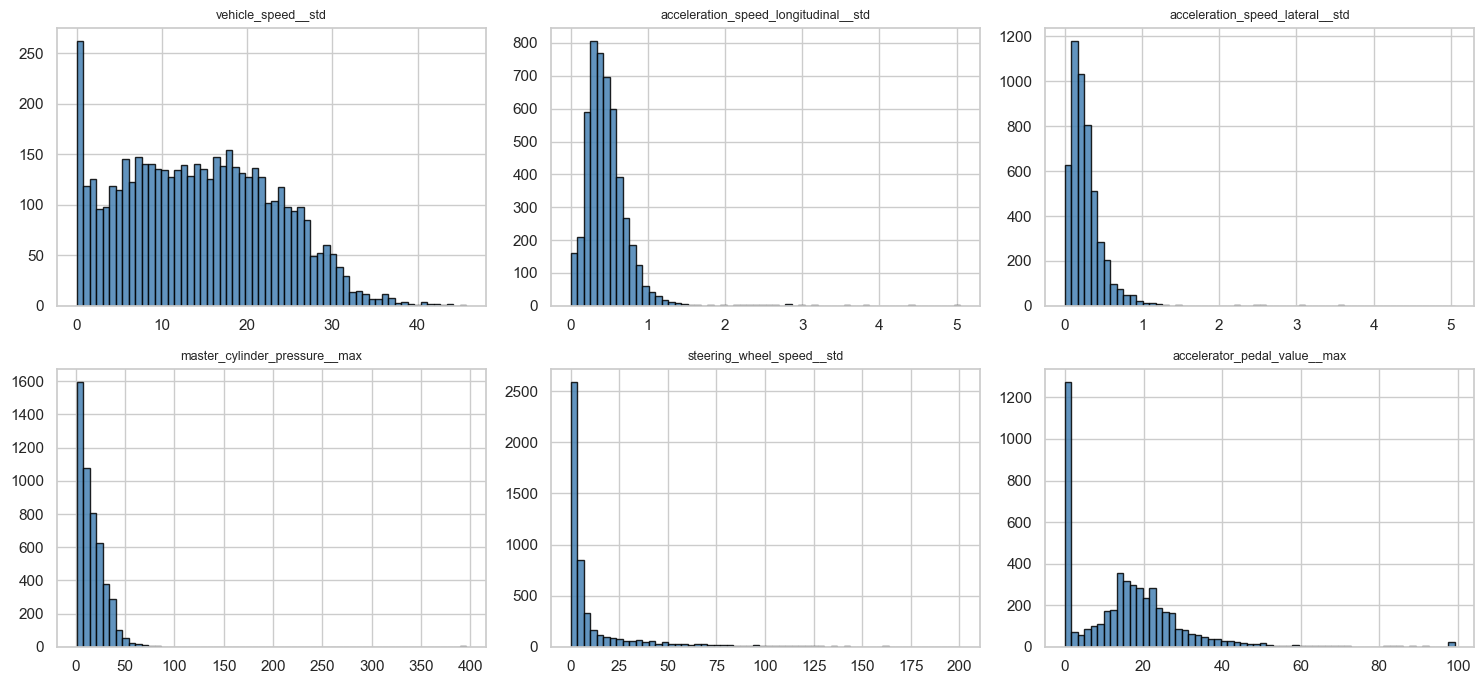

In [3]:
df = load_cleaned()
windows = build_window_feature_table(df, window_size=5, sensors=BEHAVIOR_SENSORS)
print("windows:", windows.shape)

key_cols = [
    "vehicle_speed__std",
    "acceleration_speed_longitudinal__std",
    "acceleration_speed_lateral__std",
    "master_cylinder_pressure__max",
    "steering_wheel_speed__std",
    "accelerator_pedal_value__max",
]
key_cols = [c for c in key_cols if c in windows.columns]

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, col in zip(axes.flat, key_cols):
    ax.hist(windows[col].dropna(), bins=60, color="steelblue", edgecolor="black", alpha=0.85)
    ax.set_title(col, fontsize=9)
plt.tight_layout(); plt.show()


## 2. Heuristic composite risk score

Six indicators of aggressive driving, each scaled with `RobustScaler`
(median / IQR, so heavy tails don't dominate), then averaged into a 0..1
score. This is a *prior*, not a label: it tells the model nothing - we
just use it later to inspect whether the anomaly detectors agree with
common-sense indicators of risk.


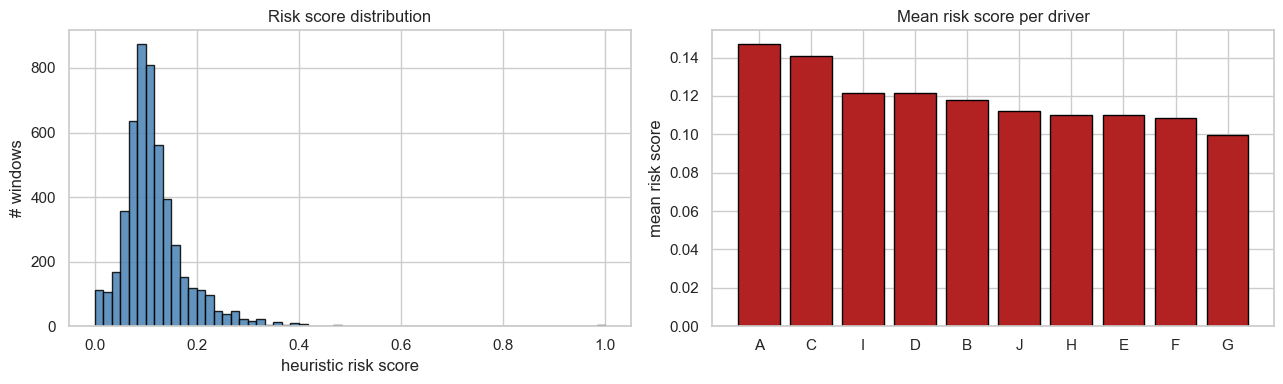

In [4]:
risk_components = {
    "speed_var":     "vehicle_speed__std",
    "long_accel":    "acceleration_speed_longitudinal__std",
    "lat_accel":     "acceleration_speed_lateral__std",
    "brake_peak":    "master_cylinder_pressure__max",
    "steering_var":  "steering_wheel_speed__std",
    "throttle_peak": "accelerator_pedal_value__max",
}
present = {k: v for k, v in risk_components.items() if v in windows.columns}
rc_df = windows[list(present.values())].fillna(0.0)
rc_scaled = RobustScaler().fit_transform(rc_df)
raw_score = rc_scaled.mean(axis=1)
# min-max to 0..1
windows["risk_score"] = (raw_score - raw_score.min()) / (raw_score.max() - raw_score.min() + 1e-12)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(windows["risk_score"], bins=60, color="steelblue", edgecolor="black", alpha=0.85)
axes[0].set_xlabel("heuristic risk score"); axes[0].set_ylabel("# windows")
axes[0].set_title("Risk score distribution")

per_driver = windows.groupby("driver_id")["risk_score"].mean().sort_values(ascending=False)
axes[1].bar(per_driver.index, per_driver.values, color="firebrick", edgecolor="black")
axes[1].set_ylabel("mean risk score")
axes[1].set_title("Mean risk score per driver")
plt.tight_layout(); plt.show()


## 3. Fit three anomaly detectors on the full feature set

In [5]:
feat_cols = feature_columns(windows)
X = windows[feat_cols].fillna(0.0).to_numpy()
X_scaled = StandardScaler().fit_transform(X)
print("feature matrix:", X_scaled.shape)


feature matrix: (4997, 61)


In [6]:
iso = IsolationForest(n_estimators=300, contamination=CONTAMINATION,
                      random_state=RNG, n_jobs=-1)
windows["iso_anom"] = (iso.fit_predict(X_scaled) == -1).astype(int)
windows["iso_score"] = -iso.score_samples(X_scaled)  # higher = more anomalous

oc = OneClassSVM(kernel="rbf", gamma="scale", nu=CONTAMINATION)
windows["svm_anom"] = (oc.fit_predict(X_scaled) == -1).astype(int)
windows["svm_score"] = -oc.score_samples(X_scaled)

lof = LocalOutlierFactor(n_neighbors=35, contamination=CONTAMINATION, n_jobs=-1)
windows["lof_anom"] = (lof.fit_predict(X_scaled) == -1).astype(int)
windows["lof_score"] = -lof.negative_outlier_factor_  # higher = more anomalous

for col in ["iso_anom", "svm_anom", "lof_anom"]:
    rate = 100 * windows[col].mean()
    print(f"{col:>8}  flagged {windows[col].sum():>4} / {len(windows)} windows  ({rate:.1f}%)")


iso_anom  flagged  750 / 4997 windows  (15.0%)
svm_anom  flagged  753 / 4997 windows  (15.1%)
lof_anom  flagged  750 / 4997 windows  (15.0%)


### Cross-model agreement

In [7]:
pair_agree = pd.DataFrame(
    index=["iso_anom", "svm_anom", "lof_anom"],
    columns=["iso_anom", "svm_anom", "lof_anom"],
    dtype=float,
)
for a in pair_agree.index:
    for b in pair_agree.columns:
        # Fraction of windows where both detectors agree on the label.
        pair_agree.loc[a, b] = (windows[a] == windows[b]).mean()
pair_agree.round(3)


,iso_anom,svm_anom,lof_anom
iso_anom,1.000,0.929,0.860
svm_anom,0.929,1.000,0.884
lof_anom,0.860,0.884,1.000


In [8]:
vote = windows[["iso_anom", "svm_anom", "lof_anom"]].sum(axis=1)
windows["consensus_anom"] = (vote >= 2).astype(int)   # majority vote
windows["unanimous_anom"] = (vote == 3).astype(int)   # all three agree

print("consensus (>=2/3): ", windows["consensus_anom"].sum(),
      f"({100*windows['consensus_anom'].mean():.1f}%)")
print("unanimous (3/3) : ", windows["unanimous_anom"].sum(),
      f"({100*windows['unanimous_anom'].mean():.1f}%)")


consensus (>=2/3):  692 (13.8%)
unanimous (3/3) :  372 (7.4%)


## 4. Do the anomalies overlap with the heuristic risk score?

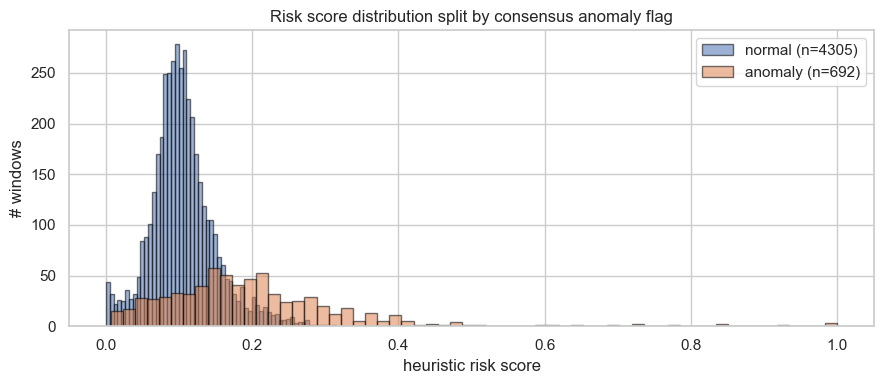

mean risk score on flagged anomalies: 0.197
mean risk score on normal windows  : 0.105


In [9]:
fig, ax = plt.subplots(figsize=(9, 4))
for label, kind in [(0, "normal"), (1, "anomaly")]:
    sub = windows.loc[windows["consensus_anom"] == label, "risk_score"]
    ax.hist(sub, bins=60, alpha=0.55, label=f"{kind} (n={len(sub)})",
            edgecolor="black")
ax.set_xlabel("heuristic risk score"); ax.set_ylabel("# windows")
ax.set_title("Risk score distribution split by consensus anomaly flag")
ax.legend(); plt.tight_layout(); plt.show()

print("mean risk score on flagged anomalies:",
      windows.loc[windows.consensus_anom == 1, "risk_score"].mean().round(3))
print("mean risk score on normal windows  :",
      windows.loc[windows.consensus_anom == 0, "risk_score"].mean().round(3))


## 5. PCA view

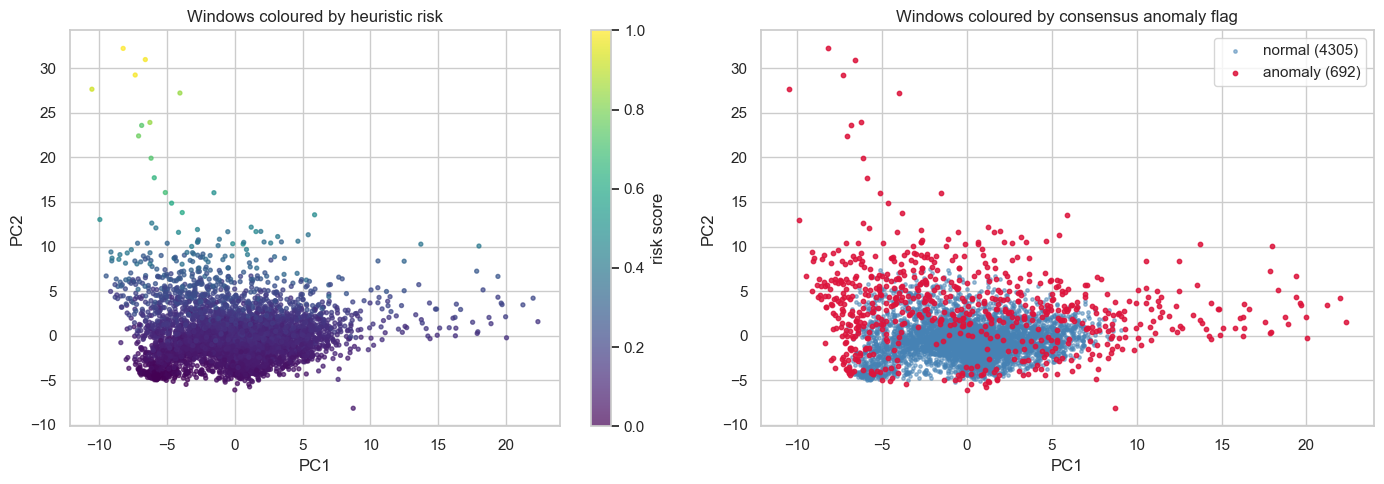

In [10]:
pca = PCA(n_components=2, random_state=RNG)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sc = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=windows["risk_score"],
                     cmap="viridis", s=8, alpha=0.7)
plt.colorbar(sc, ax=axes[0], label="risk score")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
axes[0].set_title("Windows coloured by heuristic risk")

normal = windows["consensus_anom"] == 0
anom = ~normal
axes[1].scatter(X_pca[normal, 0], X_pca[normal, 1], s=6, color="steelblue",
                alpha=0.5, label=f"normal ({normal.sum()})")
axes[1].scatter(X_pca[anom, 0], X_pca[anom, 1], s=10, color="crimson",
                alpha=0.85, label=f"anomaly ({anom.sum()})")
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")
axes[1].set_title("Windows coloured by consensus anomaly flag")
axes[1].legend(); plt.tight_layout(); plt.show()


## 6. Per-driver summary

A driver's "risk level" is taken to be the fraction of their windows that
the ensemble flagged as anomalous. We threshold this to assign
**low / medium / high** purely for reporting - the thresholds are
arbitrary and should be calibrated against ground-truth labels in any
real deployment.


In [11]:
def risk_level(ratio: float) -> str:
    if ratio >= 0.30: return "high"
    if ratio >= 0.15: return "medium"
    return "low"

summary = (windows.groupby("driver_id")
                   .agg(n_windows=("global_window_id", "count"),
                        mean_risk=("risk_score", "mean"),
                        iso_rate=("iso_anom", "mean"),
                        svm_rate=("svm_anom", "mean"),
                        lof_rate=("lof_anom", "mean"),
                        consensus_rate=("consensus_anom", "mean"))
                   .round(3)
                   .sort_values("consensus_rate", ascending=False))
summary["risk_level"] = summary["consensus_rate"].apply(risk_level)
summary


,n_windows,mean_risk,iso_rate,svm_rate,lof_rate,consensus_rate,risk_level
driver_id,,,,,,,
A,406,0.147,0.372,0.335,0.254,0.330,high
C,404,0.141,0.240,0.228,0.213,0.203,medium
J,590,0.112,0.136,0.139,0.181,0.142,low
E,556,0.110,0.126,0.140,0.191,0.138,low
H,575,0.110,0.117,0.132,0.139,0.113,low
I,433,0.122,0.122,0.134,0.106,0.109,low
F,587,0.108,0.094,0.114,0.082,0.109,low
G,408,0.100,0.108,0.130,0.115,0.103,low
D,527,0.122,0.110,0.108,0.148,0.095,low


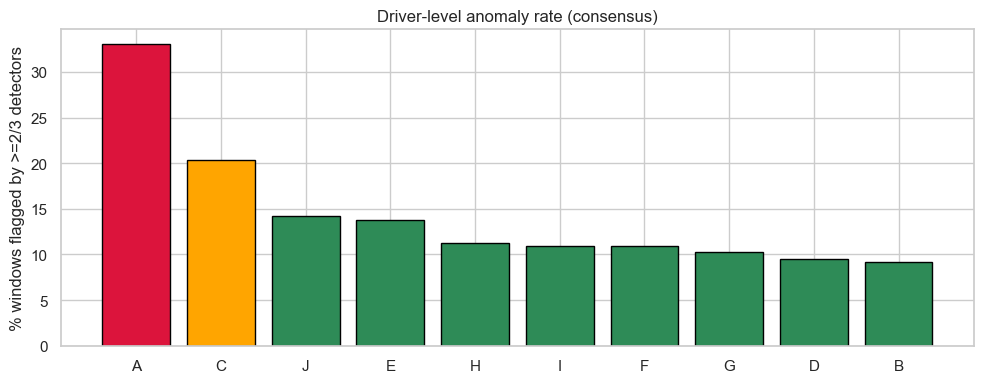

In [12]:
fig, ax = plt.subplots(figsize=(10, 4))
order = summary.index.tolist()
color_map = {"low": "seagreen", "medium": "orange", "high": "crimson"}
colors = [color_map[lvl] for lvl in summary["risk_level"]]
ax.bar(order, summary["consensus_rate"] * 100, color=colors, edgecolor="black")
ax.set_ylabel("% windows flagged by >=2/3 detectors")
ax.set_title("Driver-level anomaly rate (consensus)")
plt.tight_layout(); plt.show()


## 7. Which features matter most for the anomaly score?

We use permutation importance against the Isolation-Forest anomaly score.
This tells us which sensor-statistics drive the flagged-anomaly decisions.


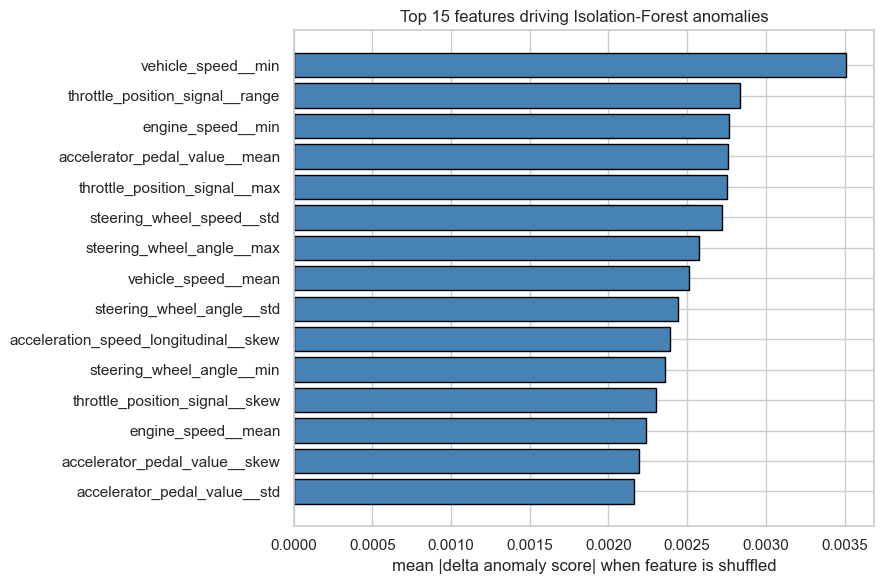

,feature,importance
2,vehicle_speed__min,0.003512
28,throttle_position_signal__range,0.002834
20,engine_speed__min,0.002765
30,accelerator_pedal_value__mean,0.002760
27,throttle_position_signal__max,0.002754
43,steering_wheel_speed__std,0.002719
51,steering_wheel_angle__max,0.002577
0,vehicle_speed__mean,0.002512
49,steering_wheel_angle__std,0.002444
11,acceleration_speed_longitudinal__skew,0.002392


In [14]:
from sklearn.utils import resample, check_random_state

# Manual permutation importance against the Isolation-Forest anomaly score.
# For each feature j we shuffle column j and measure how much the
# predicted anomaly score changes on average. Bigger change => feature j
# matters more to the decision.

rng = check_random_state(RNG)
idx = resample(np.arange(len(X_scaled)), n_samples=min(3000, len(X_scaled)),
               random_state=RNG)
X_sub = X_scaled[idx]
baseline = -iso.score_samples(X_sub)  # higher = more anomalous

n_repeats = 5
imp_values = np.zeros(X_sub.shape[1])
for j in range(X_sub.shape[1]):
    diffs = np.empty(n_repeats)
    for r in range(n_repeats):
        X_p = X_sub.copy()
        rng.shuffle(X_p[:, j])
        scores_p = -iso.score_samples(X_p)
        diffs[r] = np.mean(np.abs(scores_p - baseline))
    imp_values[j] = diffs.mean()

imp = (pd.DataFrame({"feature": feat_cols, "importance": imp_values})
         .sort_values("importance", ascending=False)
         .head(15))

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(imp["feature"][::-1], imp["importance"][::-1], color="steelblue", edgecolor="black")
ax.set_xlabel("mean |delta anomaly score| when feature is shuffled")
ax.set_title("Top 15 features driving Isolation-Forest anomalies")
plt.tight_layout(); plt.show()
imp

## 8. Save outputs

In [15]:
OUT_DIR = ROOT / "reports" / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

windows_out_cols = ["driver_id", "window_id", "global_window_id", "n_rows",
                    "risk_score",
                    "iso_anom", "iso_score",
                    "svm_anom", "svm_score",
                    "lof_anom", "lof_score",
                    "consensus_anom", "unanimous_anom"]
windows[windows_out_cols].to_csv(OUT_DIR / "driver_risk_windows_anomaly.csv", index=False)
summary.to_csv(OUT_DIR / "driver_risk_summary_anomaly.csv")
print("saved:",
      (OUT_DIR / "driver_risk_windows_anomaly.csv").relative_to(ROOT),
      "and",
      (OUT_DIR / "driver_risk_summary_anomaly.csv").relative_to(ROOT))


saved: reports\outputs\driver_risk_windows_anomaly.csv and reports\outputs\driver_risk_summary_anomaly.csv
